# Baroclinic instability of a computational time

Here we plot BICK for the superregional aus domain
from here:
https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2024MS004600
we want

$$L_{\text{layer}} = \frac{N\,\delta z}{f}\ \lesssim\ \frac{\delta x}{2}
\qquad\Longleftrightarrow\qquad
\boxed{\ \dfrac{\delta x}{\delta z} \;>\; \dfrac{2N}{f}\ }$$

Which gives us:

$$R_{\rm BICK} \;=\; \frac{\delta x/\delta z}{2N/|f|}
\;=\; \frac{\delta x\,|f|}{2\,N\,\delta z},
\qquad R_{\rm BICK} > 1 \Rightarrow \text{no BICK.}$$

### Key references
Arakawa & Moorthi (1988, *J. Atmos. Sci.* **45**, 1688) · Ménesguen, Claire, et al. Journal of Advances in Modeling Earth Systems 17.4 (2025)


## 1. Imports

In [1]:
import os
from glob import glob

import numpy as np
import pandas as pd
import xarray as xr
import gsw
import cmocean
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

xr.set_options(keep_attrs=True)
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

from dask.distributed import Client

client = Client(n_workers=14, threads_per_worker=1, memory_limit="63GB")
client

In [2]:
# ---- input data (Gadi / NCI) -----------------------------------------
ARCHIVE = "/scratch/tm70/hm6113/access-om3/archive/expt8_5years-B0_combo_3mo-2f3a552f"
THETAO_PATTERN = "output*/access-om3.mom6.3d.thetao.1month.mean*.nc"
SO_PATTERN     = "output*/access-om3.mom6.3d.so.1month.mean*.nc"

HGRID = "/g/data/tm70/hm6113/superaus/expt8/ocean_hgrid.nc"   # MOM6 supergrid (2x resolution)
VGRID = "/g/data/tm70/hm6113/superaus/expt8/ocean_vgrid.nc"   # native 75-level vertical grid

YEARS = None            # e.g. [2013] to test fast; None -> all 5 years (60 months)

# ---- output --------------------------------------------------------
OUTDIR = "/scratch/tm70/hm6113/bick_analysis"
FIGDIR = os.path.join(OUTDIR, "figures")
os.makedirs(FIGDIR, exist_ok=True)
SAVE_3D = False         # also write full 3-D N2 / BICK-ratio fields (large: tens of GB)

# ---- physics / analysis choices ------------------------------------
OMEGA         = 7.2921e-5   # Earth rotation rate [s-1]
EQ_MASK_LAT   = 5.0         # blank |lat| < this (deg): 2N/f blows up as f -> 0
N2_FLOOR      = 1e-8        # floor on N^2 [s-2]  (N ~ 1e-4 s-1)
SMOOTH_N2_NPT = 3           # vertical running-mean window on N^2 (points; 1 = none)

MAP_DEPTHS = [30.0, 100.0, 300.0, 1000.0]      # depths (m) for horizontal ratio maps

# vertical sections:  (label, kind, value)     kind = 'zonal' (fixed lat) | 'meridional' (fixed lon)
SECTIONS = [
    ("30S zonal",                      "zonal",      -30.0),
    ("EAC / Tasman (155E)",            "meridional", 155.0),
    ("S. of Tasmania (147E)",          "meridional", 147.0),
    ("West Australia / Leeuwin (112E)", "meridional", 112.0),
]

# representative regions for the baroclinic-mode analysis:  (lon0, lon1, lat0, lat1)
REGION_BOXES = {
    "EAC core":                (153.5, 156.0, -34.0, -30.0),
    "Tasman interior":         (158.0, 162.0, -40.0, -36.0),
    "S. Ocean S of Tasmania":  (145.0, 149.0, -52.0, -47.0),
    "Great Australian Bight":  (129.0, 133.0, -38.0, -35.0),
    "Leeuwin / WA west":       (110.0, 113.0, -32.0, -28.0),
    "NW shelf":                (117.0, 121.0, -17.0, -13.0),
    "Subtropical Indian gyre": (95.0,  100.0, -30.0, -25.0),
}

NMODES = 6                              # baroclinic modes to examine
CANDIDATE_NLEVS = [50, 60, 75, 90, 110] # candidate vertical grids to score (75 = native)
SCORE_LATS  = [-35.0, -45.0]            # reference latitudes for the 2N/f scoring
SCORE_DX_KM = 4.0

SEASONS = ["ANN", "DJF", "JJA"]

## Checking the resolution

`ocean_hgrid.nc` is a **supergrid** at twice the model resolution. Model **tracer
(h-) points** sit on the *odd* supergrid indices, and a tracer cell's width is the
**sum of the two supergrid edge lengths** that span it. There is no `ocean_static.nc`
in this experiment, so we build `dxt, dyt, geolon, geolat` here.

In [4]:
sg = xr.open_dataset(HGRID)

# tracer points = odd/odd supergrid nodes
geolon = sg["x"].values[1::2, 1::2]
geolat = sg["y"].values[1::2, 1::2]
ny, nx = geolon.shape

# dx(nyp, nx): edge lengths along i. Take the tracer ROW (odd j), sum pairs along i.
dxt = sg["dx"].values[1::2, :].reshape(ny, nx, 2).sum(axis=2)      # (ny, nx) metres
# dy(ny, nxp): edge lengths along j. Take the tracer COLUMN (odd i), sum pairs along j.
dyt = sg["dy"].values[:, 1::2].reshape(ny, 2, nx).sum(axis=1)      # (ny, nx) metres
area_t = sg["area"].values.reshape(ny, 2, nx, 2).sum(axis=(1, 3))
sg.close()

# 1-D nominal lon/lat axes (this grid's global attr grid_type = "regular")
xh = np.nanmean(geolon, axis=0)
yh = np.nanmean(geolat, axis=1)
assert np.all(np.diff(xh) > 0) and np.all(np.diff(yh) > 0), \
    "xh/yh not monotonically increasing - a domain crossing 180E needs +360 on negative lon"

grid = xr.Dataset(
    data_vars=dict(
        dxt=(("yh", "xh"), dxt),
        dyt=(("yh", "xh"), dyt),
        geolon=(("yh", "xh"), geolon),
        geolat=(("yh", "xh"), geolat),
        dx_km=(("yh", "xh"), dxt / 1e3),
        dy_km=(("yh", "xh"), dyt / 1e3),
        sqrt_area_km=(("yh", "xh"), np.sqrt(area_t) / 1e3),
        aniso=(("yh", "xh"), dxt / dyt),
    ),
    coords=dict(xh=("xh", xh), yh=("yh", yh)),
)

print(grid, "\n")
print(f"lon {xh.min():.2f} .. {xh.max():.2f}    lat {yh.min():.2f} .. {yh.max():.2f}\n")
for v in ["dx_km", "dy_km", "sqrt_area_km"]:
    a = grid[v].values
    print(f"  {v:13s} min={np.nanmin(a):5.2f}  median={np.nanmedian(a):5.2f}  max={np.nanmax(a):5.2f}")
print(f"\n  fraction of cells with 3.5 < dx < 4.5 km:  "
      f"{np.mean((grid.dx_km.values > 3.5) & (grid.dx_km.values < 4.5)):.1%}")

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:38: UserWarning: An error occurred while loading the ERDDAP data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:50: UserWarning: An error occurred while loading the ArgoVis data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:66: UserWarning: An error occurred while loadi

<xarray.Dataset> Size: 260MB
Dimensions:       (yh: 1936, xh: 2100)
Coordinates:
  * yh            (yh) float64 15kB -54.99 -54.96 -54.93 ... 2.925 2.955 2.985
  * xh            (xh) float64 17kB 105.0 105.0 105.1 ... 174.9 175.0 175.0
Data variables:
    dxt           (yh, xh) float64 33MB 2.127e+03 2.127e+03 ... 3.701e+03
    dyt           (yh, xh) float64 33MB 3.331e+03 3.331e+03 ... 3.331e+03
    geolon        (yh, xh) float64 33MB 105.0 105.0 105.1 ... 174.9 174.9 175.0
    geolat        (yh, xh) float64 33MB -54.99 -54.99 -54.99 ... 2.985 2.985
    dx_km         (yh, xh) float64 33MB 2.127 2.127 2.127 ... 3.701 3.701 3.701
    dy_km         (yh, xh) float64 33MB 3.331 3.331 3.331 ... 3.331 3.331 3.331
    sqrt_area_km  (yh, xh) float64 33MB 2.662 2.662 2.662 ... 3.511 3.511 3.511
    aniso         (yh, xh) float64 33MB 0.6384 0.6384 0.6384 ... 1.111 1.111 

lon 105.02 .. 174.98    lat -54.99 .. 2.99

  dx_km         min= 2.13  median= 3.33  max= 3.71
  dy_km         min= 3.33  me

## Plotting the resolution

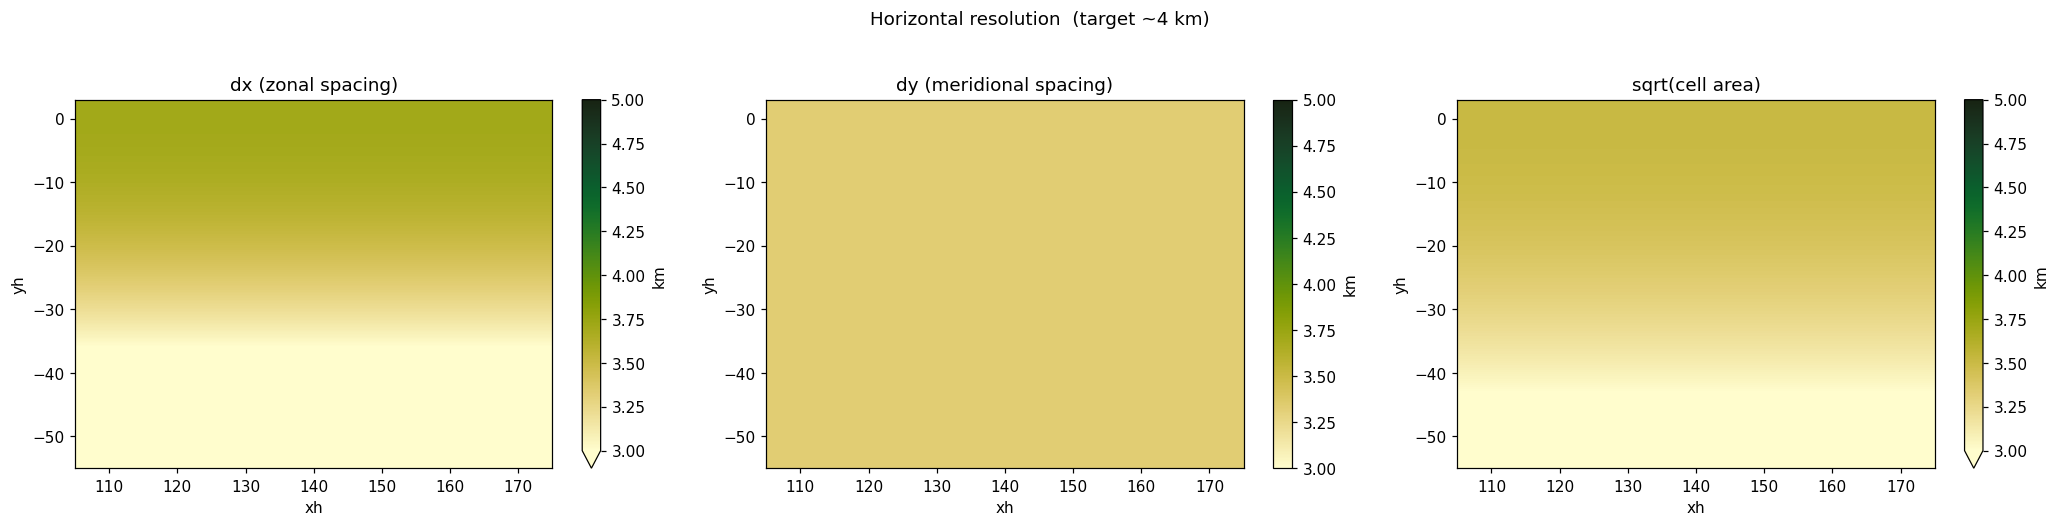

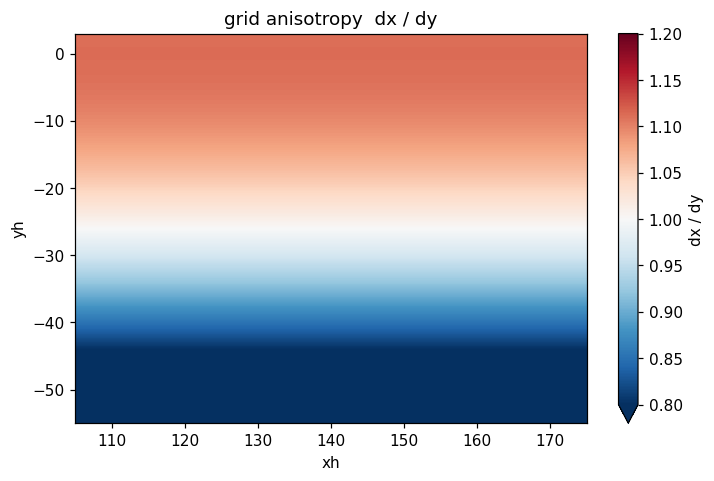

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(19, 4.6))
grid.dx_km.plot(ax=axs[0], x="xh", y="yh", cmap=cmocean.cm.speed, vmin=3, vmax=5,
                cbar_kwargs=dict(label="km"))
grid.dy_km.plot(ax=axs[1], x="xh", y="yh", cmap=cmocean.cm.speed, vmin=3, vmax=5,
                cbar_kwargs=dict(label="km"))
grid.sqrt_area_km.plot(ax=axs[2], x="xh", y="yh", cmap=cmocean.cm.speed, vmin=3, vmax=5,
                       cbar_kwargs=dict(label="km"))
axs[0].set_title("dx (zonal spacing)")
axs[1].set_title("dy (meridional spacing)")
axs[2].set_title("sqrt(cell area)")
fig.suptitle("Horizontal resolution  (target ~4 km)", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "horizontal_resolution.png"), bbox_inches="tight")

plt.figure(figsize=(7.5, 4.6))
grid.aniso.plot(x="xh", y="yh", cmap="RdBu_r", vmin=0.8, vmax=1.2,
                cbar_kwargs=dict(label="dx / dy"))
plt.title("grid anisotropy  dx / dy")
plt.savefig(os.path.join(FIGDIR, "horizontal_anisotropy.png"), bbox_inches="tight")

## Plotting the vertical grid

native grid: 75 levels, bottom interface 4500.0 m
dz: surface 2.18 m  ->  max 117.8 m near 4441 m
levels in upper 200 m: 29;  upper 1000 m: 44


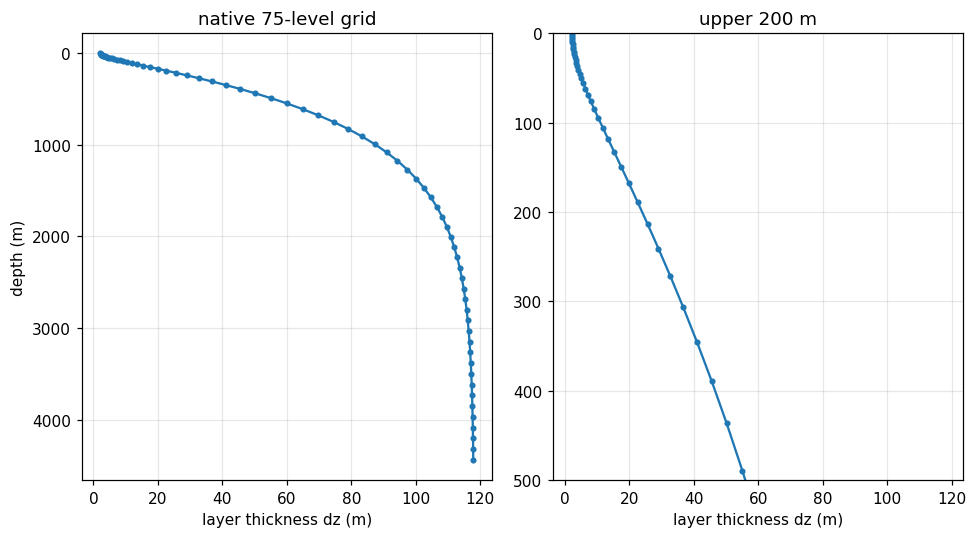

In [25]:
vg = xr.open_dataset(VGRID)
zi = vg["zi"].values                       # 76 interface depths [m], positive down
zl = vg["zl"].values                       # 75 cell-centre depths [m]
dz = np.diff(zi)                           # 75 layer thicknesses [m]
H_native = float(zi[-1])
vg.close()

print(f"native grid: {zl.size} levels, bottom interface {H_native:.1f} m")
print(f"dz: surface {dz[0]:.2f} m  ->  max {dz.max():.1f} m near {zl[dz.argmax()]:.0f} m")
print(f"levels in upper 200 m: {(zl < 200).sum()};  upper 1000 m: {(zl < 1000).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(9, 5))
for a in ax:
    a.plot(dz, zl, "o-", ms=3)
    a.set_xlabel("layer thickness dz (m)")
    a.grid(alpha=.3)
ax[0].invert_yaxis(); ax[0].set_ylabel("depth (m)"); ax[0].set_title("native 75-level grid")
ax[1].set_ylim(500, 0);                              ax[1].set_title("upper 200 m")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "native_vgrid.png"), bbox_inches="tight")

# Reading in the data

In [7]:
theta_files = sorted(glob(os.path.join(ARCHIVE, THETAO_PATTERN)))
so_files    = sorted(glob(os.path.join(ARCHIVE, SO_PATTERN)))
if YEARS is not None:
    theta_files = [f for f in theta_files if any(f"mean{y}-" in f for y in YEARS)]
    so_files    = [f for f in so_files    if any(f"mean{y}-" in f for y in YEARS)]

print(f"thetao files: {len(theta_files)}   so files: {len(so_files)}")
print("first:", os.path.basename(theta_files[0]))
print("last :", os.path.basename(theta_files[-1]))
assert len(theta_files) == len(so_files) > 0

open_kw = dict(combine="nested", concat_dim="time", data_vars="minimal",
               coords="minimal", compat="override", parallel=True,
               chunks={"time": 1, "z_l": -1, "yh": 484, "xh": 525})

ds_t = xr.open_mfdataset(theta_files, **open_kw)
ds_s = xr.open_mfdataset(so_files, **open_kw)

ds = xr.Dataset(dict(thetao=ds_t["thetao"], so=ds_s["so"]))
ds = ds.assign_coords(geolon=(("yh", "xh"), grid.geolon.data),
                      geolat=(("yh", "xh"), grid.geolat.data))
ds["dxt"] = (("yh", "xh"), grid.dxt.data)
ds["dyt"] = (("yh", "xh"), grid.dyt.data)
ds["dz"]  = (("z_l",), dz)

assert np.allclose(zl, ds["z_l"].values, rtol=2e-3), "vgrid zl != file z_l - check VGRID path"
assert np.all(np.diff(ds.xh.values) > 0) and np.all(np.diff(ds.yh.values) > 0), \
    "file xh/yh not increasing - a domain crossing 180E needs +360 on negative lon"
ds

thetao files: 60   so files: 60
first: access-om3.mom6.3d.thetao.1month.mean2013-01.nc
last : access-om3.mom6.3d.thetao.1month.mean2017-12.nc


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:38: UserWarning: An error occurred while loading the ERDDAP data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:50: UserWarning: An error occurred while loading the ArgoVis data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:66: UserWarning: An error occurred while loadi

<xarray.Dataset> Size: 146GB
Dimensions:  (xh: 2100, yh: 1936, z_l: 75, time: 60)
Coordinates:
  * xh       (xh) float64 17kB 105.0 105.0 105.1 105.1 ... 174.9 174.9 175.0
    geolon   (yh, xh) float64 33MB 105.0 105.0 105.1 105.1 ... 174.9 174.9 175.0
    geolat   (yh, xh) float64 33MB -54.99 -54.99 -54.99 ... 2.985 2.985 2.985
  * yh       (yh) float64 15kB -54.99 -54.96 -54.93 -54.9 ... 2.925 2.955 2.985
  * z_l      (z_l) float64 600B 1.092 3.295 5.542 ... 4.323e+03 4.441e+03
  * time     (time) datetime64[ns] 480B 2013-01-16T12:00:00 ... 2017-12-16T12...
Data variables:
    thetao   (time, z_l, yh, xh) float32 73GB dask.array<chunksize=(1, 75, 484, 525), meta=np.ndarray>
    so       (time, z_l, yh, xh) float32 73GB dask.array<chunksize=(1, 75, 484, 525), meta=np.ndarray>
    dxt      (yh, xh) float64 33MB 2.127e+03 2.127e+03 ... 3.701e+03 3.701e+03
    dyt      (yh, xh) float64 33MB 3.331e+03 3.331e+03 ... 3.331e+03 3.331e+03
    dz       (z_l) float64 600B 2.184 2.224 2.271 2.327 ... 117.7 117.8 117.8

Text(0.5, 1.0, 'SST  2013-01-16  (sanity check)')

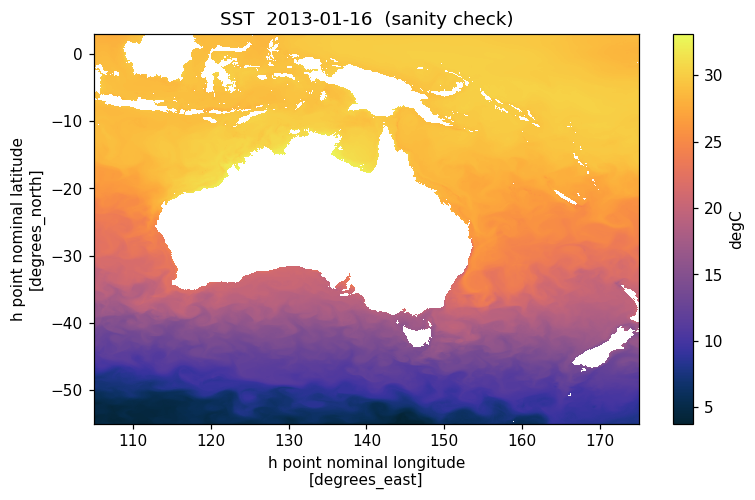

In [8]:
#plotting first time step
plt.figure(figsize=(8, 4.6))
ds["thetao"].isel(time=0, z_l=0).plot(x="xh", y="yh", cmap=cmocean.cm.thermal,
                                      cbar_kwargs=dict(label="degC"))
plt.title(f"SST  {str(ds.time.values[0])[:10]}  (sanity check)")

## Climatology  —  annual + DJF + JJA

Looking at annual and seasonal averages

In [9]:
ts = ds[["thetao", "so"]]

clim = {}
if "ANN" in SEASONS:
    clim["ANN"] = ts.mean("time")
for s in [x for x in SEASONS if x != "ANN"]:
    clim[s] = ts.sel(time=ds.time.dt.season == s).mean("time")

for k in clim:
    clim[k] = clim[k].compute()          # bring this season's T, S into memory
    clim[k]["dz"] = ds["dz"]
print("climatology in memory for:", list(clim))
clim[SEASONS[0]]

climatology in memory for: ['ANN', 'DJF', 'JJA']


<xarray.Dataset> Size: 3GB
Dimensions:  (z_l: 75, yh: 1936, xh: 2100)
Coordinates:
  * z_l      (z_l) float64 600B 1.092 3.295 5.542 ... 4.323e+03 4.441e+03
  * yh       (yh) float64 15kB -54.99 -54.96 -54.93 -54.9 ... 2.925 2.955 2.985
  * xh       (xh) float64 17kB 105.0 105.0 105.1 105.1 ... 174.9 174.9 175.0
    geolon   (yh, xh) float64 33MB 105.0 105.0 105.1 105.1 ... 174.9 174.9 175.0
    geolat   (yh, xh) float64 33MB -54.99 -54.99 -54.99 ... 2.985 2.985 2.985
Data variables:
    thetao   (z_l, yh, xh) float32 1GB 1.803 1.832 1.854 ... 0.9319 0.9279 0.922
    so       (z_l, yh, xh) float32 1GB 33.91 33.91 33.91 ... 34.7 34.7 34.7
    dz       (z_l) float64 600B 2.184 2.224 2.271 2.327 ... 117.7 117.8 117.8

## 9. Buoyancy frequency  `N²(z)`  via TEOS-10 (`gsw`)

Converting from practical salinity / potential temp to absolute sale / conservative temp. Interpolating back onto central grid. Need to do this calculation in bands

In [10]:
def n2_profile_3d(theta, salt, z, lat2d, lon2d, band=400):
    """N^2 [s^-2] at the nz cell centres.  theta, salt: (nz, ny, nx) NumPy arrays."""
    nz, ny, nx = theta.shape
    out = np.empty_like(theta)
    for j0 in range(0, ny, band):
        j  = slice(j0, min(j0 + band, ny))
        p  = gsw.p_from_z(-z[:, None, None], lat2d[None, j, :])            # (nz, nb, nx) dbar
        SA = gsw.SA_from_SP(salt[:, j, :], p, lon2d[None, j, :], lat2d[None, j, :])
        CT = gsw.CT_from_pt(SA, theta[:, j, :])
        n2, _ = gsw.Nsquared(SA, CT, p, lat=lat2d[None, j, :], axis=0)     # (nz-1, nb, nx)
        out[1:-1, j, :] = 0.5 * (n2[:-1] + n2[1:])
        out[0, j, :]    = n2[0]
        out[-1, j, :]   = n2[-1]
    return np.maximum(out, N2_FLOOR)


lat2d = clim[SEASONS[0]].geolat.values
lon2d = clim[SEASONS[0]].geolon.values

for k, cl in clim.items():
    n2 = n2_profile_3d(cl.thetao.values, cl.so.values, zl, lat2d, lon2d)
    cl["N2"] = (("z_l", "yh", "xh"), n2)
    if SMOOTH_N2_NPT > 1:
        cl["N2"] = cl["N2"].rolling(z_l=SMOOTH_N2_NPT, center=True, min_periods=1).mean()
    cl["N"] = np.sqrt(cl["N2"])
print("N2 done for:", list(clim))

N2 done for: ['ANN', 'DJF', 'JJA']


Text(0.5, 1.0, 'N^2 section at 155E  (ANN)')

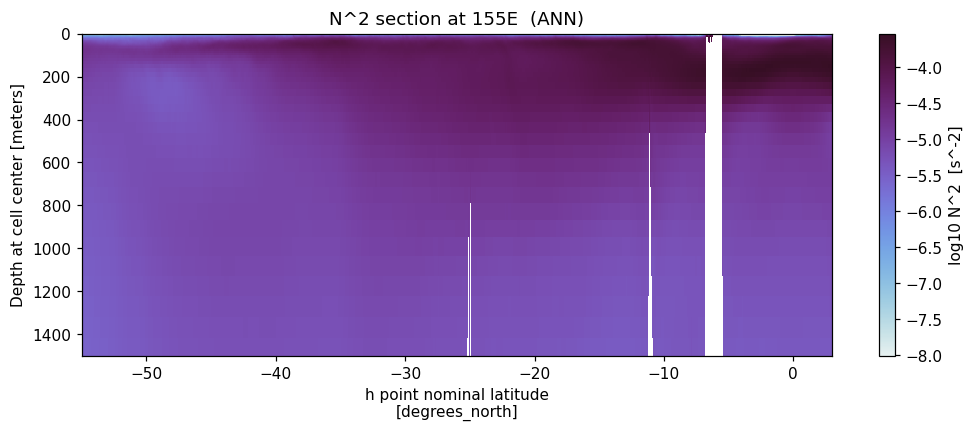

In [33]:
#plotting N^2 
sec = clim["ANN"].N2.sel(xh=155.0, method="nearest")
plt.figure(figsize=(11, 3.8))
np.log10(sec).plot(x="yh", y="z_l", yincrease=False, cmap=cmocean.cm.dense,
                   cbar_kwargs=dict(label="log10 N^2  [s^-2]"))
plt.ylim(1500, 0)
plt.title("N^2 section at 155E  (ANN)")

## 10. Masking near equator

masking |lat| < 5.0 deg  ->  13.8% of cells


Text(0.5, 1.0, '|f|   (equatorial band masked)')

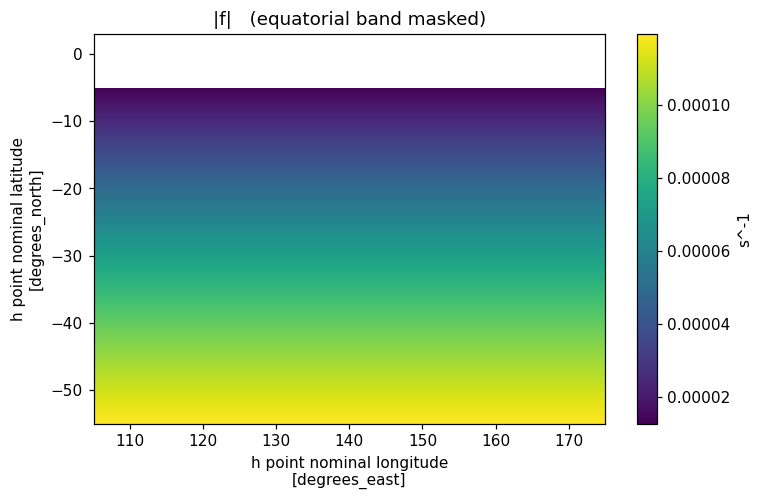

In [12]:
f = 2 * OMEGA * np.sin(np.deg2rad(ds.geolat))          # (yh, xh)
eqmask = np.abs(ds.geolat) >= EQ_MASK_LAT              # True where we KEEP data
f = f.where(eqmask)
print(f"masking |lat| < {EQ_MASK_LAT} deg  ->  {float((~eqmask).mean()):.1%} of cells")

plt.figure(figsize=(7.5, 4.6))
np.abs(f).plot(x="xh", y="yh", cmap="viridis", cbar_kwargs=dict(label="s^-1"))
plt.title("|f|   (equatorial band masked)")

## Calculating BICK ratio

From *Exploring Baroclinic Instability of the Computational Kind (BICK) in Numerical Simulations of the Ocean*

https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2024MS004600


"Our recommendation is to keep the ratio between the model horizontal (𝛿⁢𝑥) and vertical (𝛿⁢𝑧) resolution greater than 2⁢𝑁/𝑓"

$$R_{\rm BICK}=\dfrac{\delta x\,|f|}{2 N\,\delta z}
\qquad R_{\rm BICK}>1 \Rightarrow \text{good.}$$



In [26]:
bick = {}
for k, cl in clim.items():
    R = ((ds.dxt / ds.dz) / (BICK_SAFETY * cl.N / np.abs(f))).rename("R_BICK")
    if k == "ANN":
        clim["ANN"]["R_BICK"] = R                      # kept for the sections below
    wet = np.isfinite(R)
    bick[k] = xr.Dataset(dict(
        frac_viol = ((R < 1).where(wet) * ds.dz).sum("z_l") / (wet * ds.dz).sum("z_l"),
        min_500   = R.where(R.z_l <= 500).min("z_l"),
        deepest   = R.z_l.where(R < 1).max("z_l"),
    ))
bick["ANN"]

<xarray.Dataset> Size: 163MB
Dimensions:    (xh: 2100, yh: 1936)
Coordinates:
  * xh         (xh) float64 17kB 105.0 105.0 105.1 105.1 ... 174.9 174.9 175.0
    geolon     (yh, xh) float64 33MB 105.0 105.0 105.1 ... 174.9 174.9 175.0
    geolat     (yh, xh) float64 33MB -54.99 -54.99 -54.99 ... 2.985 2.985 2.985
  * yh         (yh) float64 15kB -54.99 -54.96 -54.93 ... 2.925 2.955 2.985
Data variables:
    frac_viol  (yh, xh) float64 33MB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan nan
    min_500    (yh, xh) float64 33MB 1.057 1.054 1.052 1.051 ... nan nan nan nan
    deepest    (yh, xh) float64 33MB nan nan nan nan nan ... nan nan nan nan nan

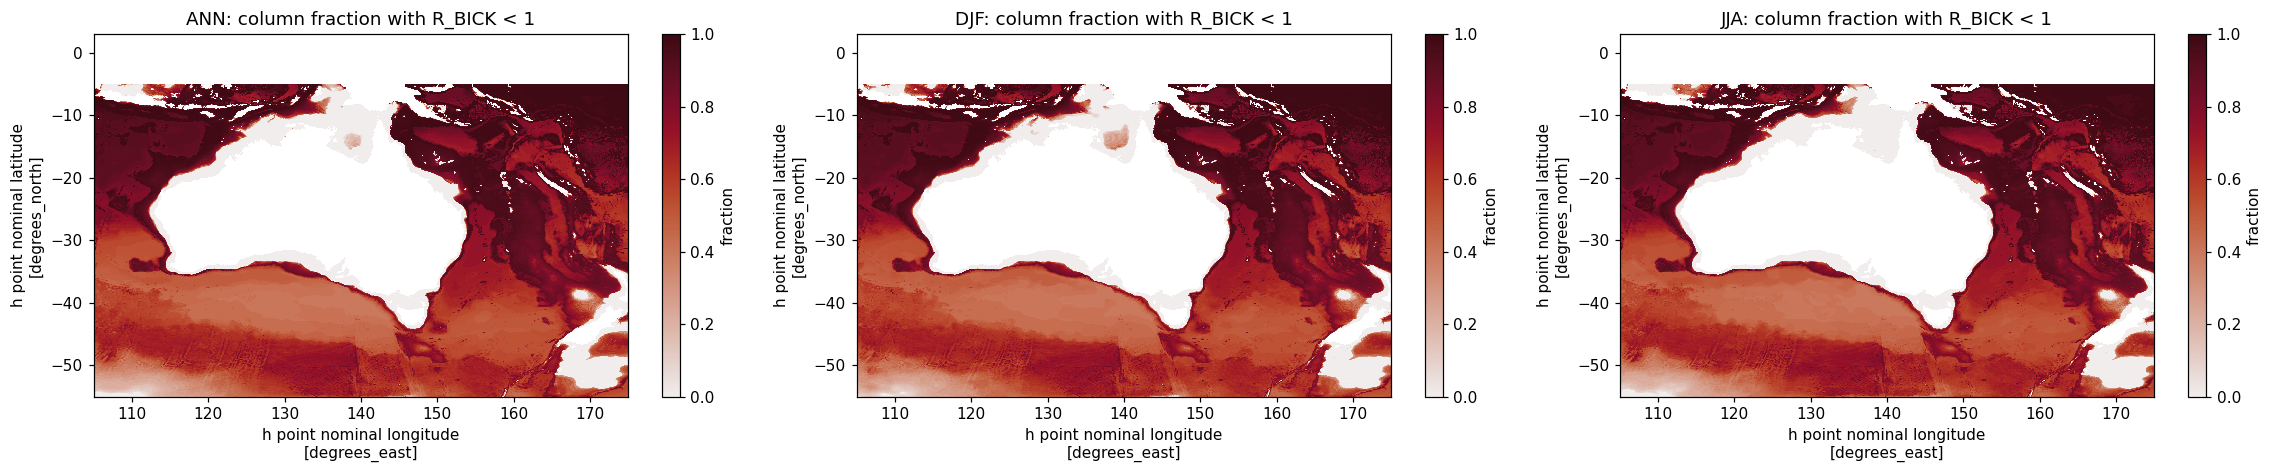

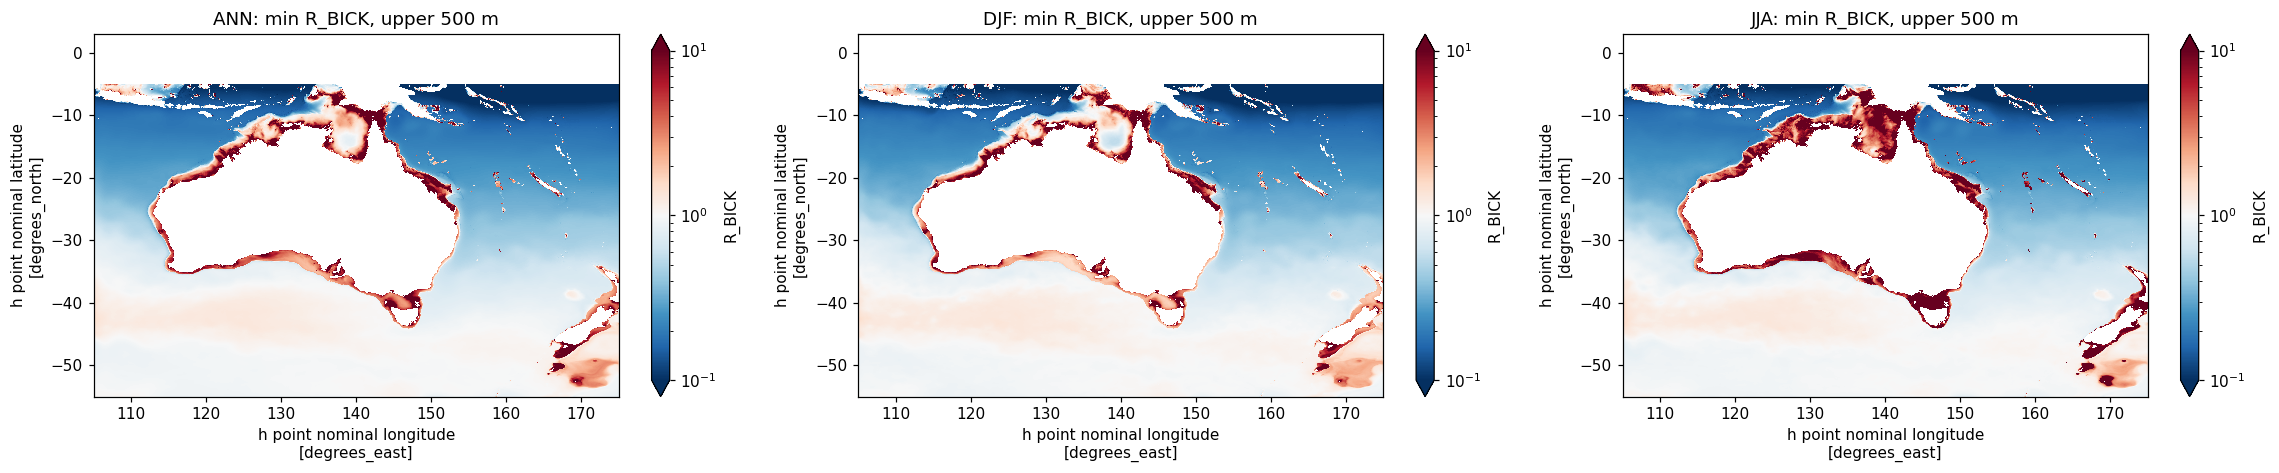

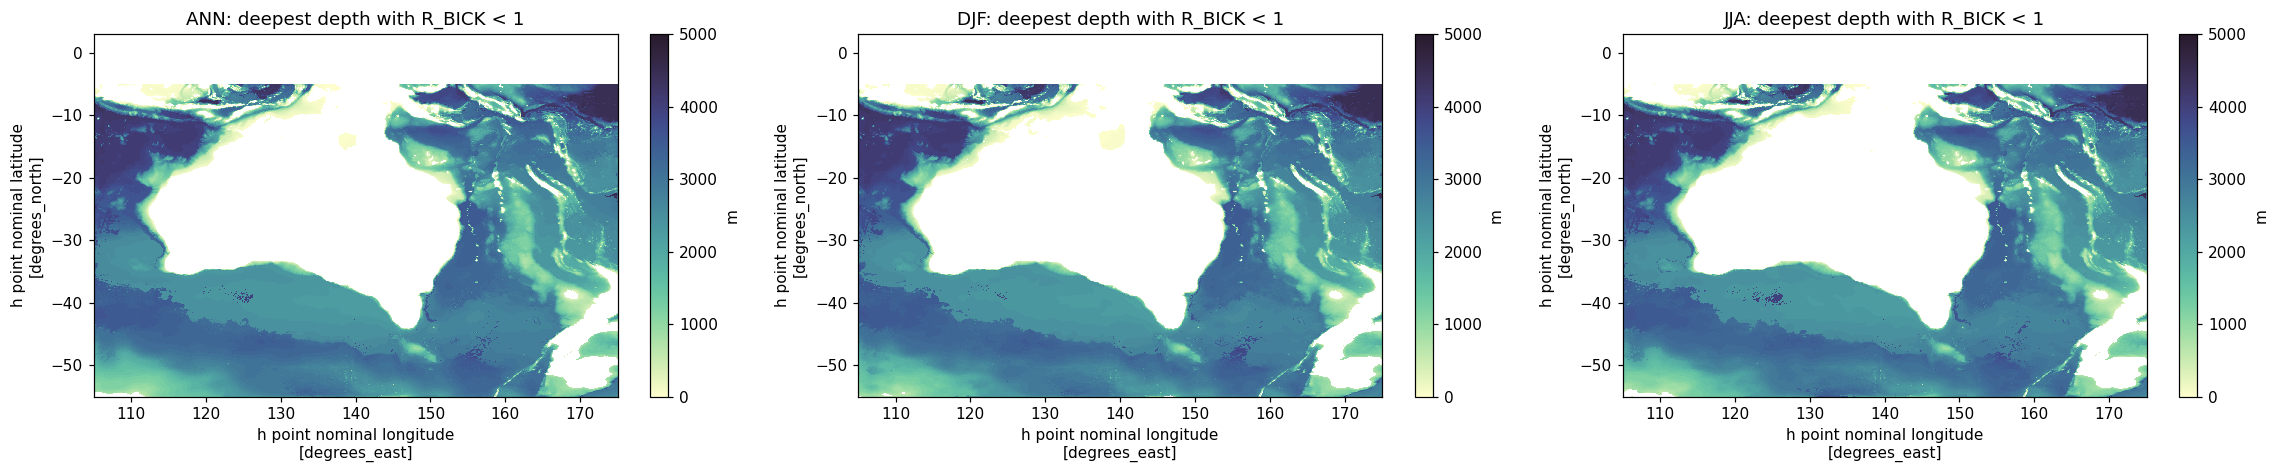

In [27]:
# fraction of the water column which has BICK
per = list(bick)
fig, axs = plt.subplots(1, len(per), figsize=(7 * len(per), 4.4))
for ax, k in zip(np.atleast_1d(axs), per):
    bick[k].frac_viol.plot(ax=ax, x="xh", y="yh", cmap=cmocean.cm.amp, vmin=0, vmax=1,
                           cbar_kwargs=dict(label="fraction"))
    ax.set_title(f"{k}: column fraction with R_BICK < 1")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "bick_frac_viol.png"), bbox_inches="tight")

# upper 500 m - lowest score  (blue < 1 = BICK present)
fig, axs = plt.subplots(1, len(per), figsize=(7 * len(per), 4.4))
for ax, k in zip(np.atleast_1d(axs), per):
    bick[k].min_500.plot(ax=ax, x="xh", y="yh", cmap="RdBu_r",
                         norm=LogNorm(vmin=0.1, vmax=10), cbar_kwargs=dict(label="R_BICK"))
    ax.set_title(f"{k}: min R_BICK, upper 500 m")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "bick_min500.png"), bbox_inches="tight")

# deepest BICK
fig, axs = plt.subplots(1, len(per), figsize=(7 * len(per), 4.4))
for ax, k in zip(np.atleast_1d(axs), per):
    bick[k].deepest.plot(ax=ax, x="xh", y="yh", cmap=cmocean.cm.deep, vmin=0, vmax=5000,
                         cbar_kwargs=dict(label="m"))
    ax.set_title(f"{k}: deepest depth with R_BICK < 1")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "bick_deepest.png"), bbox_inches="tight")

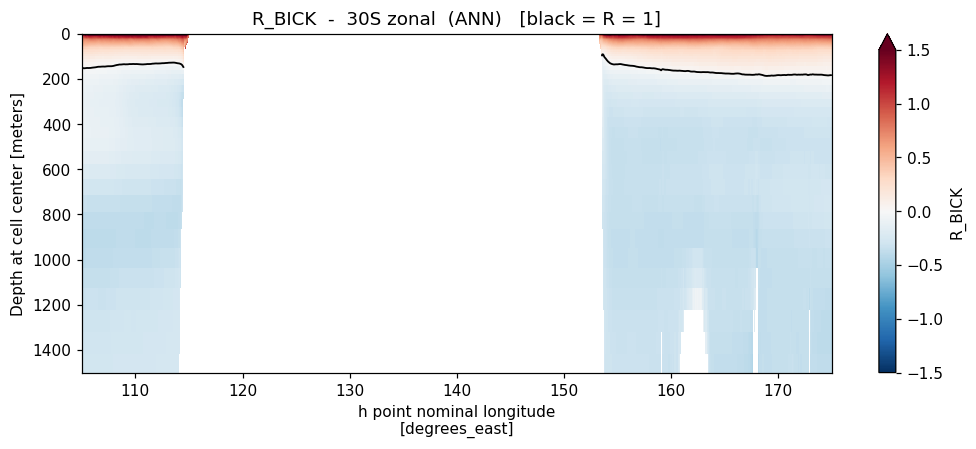

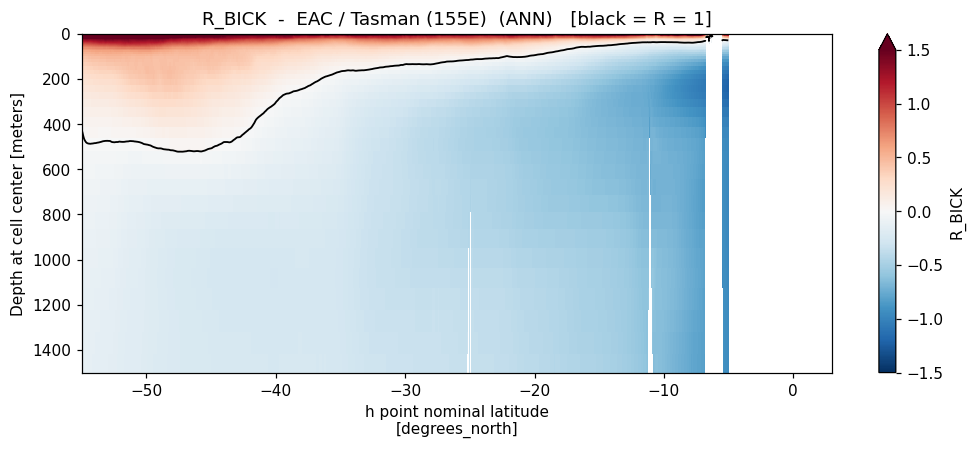

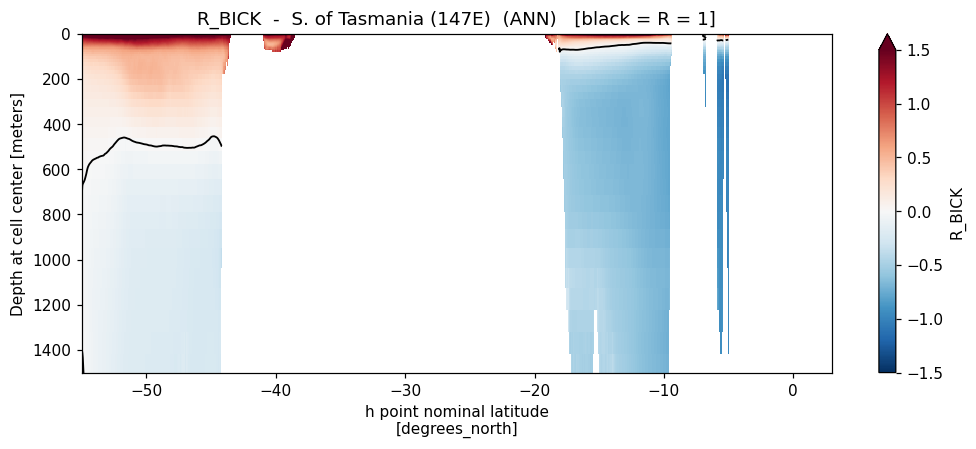

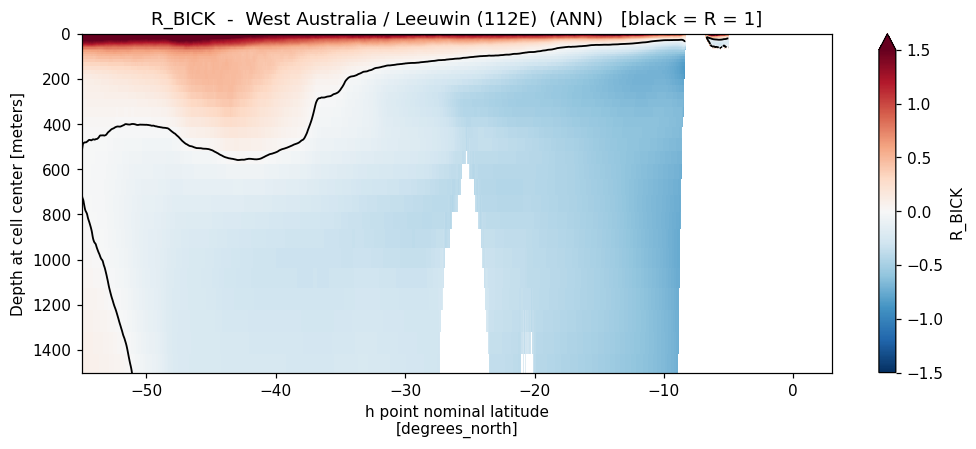

In [28]:
# vertical sections of R_BICK, annual;  black line = R = 1
for label, kind, val in SECTIONS:
    if kind == "meridional":
        sec = clim["ANN"].R_BICK.sel(xh=val, method="nearest")
        xdim = "yh"
    else:
        sec = clim["ANN"].R_BICK.sel(yh=val, method="nearest")
        xdim = "xh"
    plt.figure(figsize=(11, 4))
    np.log10(sec).plot(x=xdim, y="z_l", yincrease=False, vmin=-1.5, vmax=1.5,
                       cmap="RdBu_r", cbar_kwargs=dict(label="R_BICK"))
    np.log10(sec).plot.contour(x=xdim, y="z_l", levels=[0.0], colors="k", linewidths=1.2)
    plt.ylim(1500, 0)
    plt.title(f"R_BICK  -  {label}  (ANN)   [black = R = 1]")
    plt.savefig(os.path.join(FIGDIR, f"bick_section_{kind}_{val}.png"), bbox_inches="tight")